# Buổi 5 · Tình huống 07 — Cảnh báo thông gió phòng học (Adaline)

Notebook này dùng lại bối cảnh trong [`bai-tap/buoi4-tinh-huong/07_thong_gio_phong_hoc.py`](../../bai-tap/buoi4-tinh-huong/07_thong_gio_phong_hoc.py), nhưng thay Perceptron (0/1) bằng **Adaline** học quy tắc Widrow–Hoff (LMS) với **target liên tục**.

Không có dữ liệu hoặc lời giải dựng sẵn trong notebook này. Các code cell chỉ chứa comment định hướng; bạn tự thu thập dữ liệu, xử lý, huấn luyện, đánh giá và triển khai thử.

## Bối cảnh

Một lớp học muốn dùng cảm biến để cảnh báo khi cần mở cửa hoặc bật quạt thông gió.

Feature có thể cân nhắc: nồng độ CO2, nhiệt độ, độ ẩm, số người trong phòng, thời gian đã đóng cửa (chuẩn hoá).

## Vì sao dùng Adaline thay Perceptron?

Thay vì chỉ 0/1 (chưa cần / cần thông gió), hãy coi target là **mức độ cần thông gió** trong [0, 1], tăng dần theo nồng độ CO2 và số người trong phòng.

Nhắc lại công thức Adaline / Widrow–Hoff:

$$
\text{net} = \mathbf{w}^\top \mathbf{x} + b, \qquad e = t - \text{net}
$$

$$
\mathbf{w} \leftarrow \mathbf{w} + \eta e \mathbf{x}, \qquad b \leftarrow b + \eta e
$$

Mức độ cần thông gió liên tục giúp hệ thống điều chỉnh tốc độ quạt dần dần, thay vì chỉ bật/tắt như quyết định 0/1.

## Nhiệm vụ suy nghĩ

1. Xác định thời điểm và tần suất đọc cảm biến để tạo từng dòng dữ liệu.
2. Đề xuất cách gắn nhãn liên tục mà không dùng trực tiếp một feature làm đáp án.
3. Xử lý giá trị cảm biến bị thiếu, âm hoặc vượt phạm vi hợp lý trước khi đưa vào Adaline.
4. Huấn luyện Adaline và phân tích các mẫu có sai số dự đoán lớn nhất.
5. Thiết kế ba ca kiểm thử: bình thường, sát ngưỡng và đầu vào không hợp lệ.

Không có code mẫu hoặc lời giải trong notebook này. Bắt đầu phần triển khai ở các cell dưới.

## 1. Thu thập / tạo dữ liệu

Tự tạo hoặc thu thập một bảng dữ liệu nhỏ. Ghi rõ ý nghĩa, đơn vị của từng feature và cách bạn gán target liên tục (không chỉ 0/1).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Tự tạo dữ liệu mô phỏng cảm biến với 150 mẫu
np.random.seed(42)
n_samples = 150

# Features
CO2 = np.random.uniform(400, 2000, n_samples)       # Nồng độ CO2 (ppm)
Temp = np.random.uniform(20, 35, n_samples)         # Nhiệt độ (°C)
Humidity = np.random.uniform(40, 80, n_samples)     # Độ ẩm (%)
People = np.random.randint(0, 50, n_samples)        # Số người
Time_Closed = np.random.uniform(0, 120, n_samples)  # Thời gian đóng cửa (phút)

# Target liên tục (Công thức tuyến tính kết hợp + Nhiễu)
target_raw = (CO2/2000)*0.4 + (Temp/35)*0.3 + (People/50)*0.2 + (Time_Closed/120)*0.1
target = target_raw + np.random.normal(0, 0.05, n_samples)
t = np.clip(target, 0.0, 1.0) # Ép trong khoảng [0, 1]

X = np.column_stack((CO2, Temp, Humidity, People, Time_Closed))
print(f"Đã tạo X: {X.shape}, Target t: {t.shape}")
print(f"Mẫu đầu tiên: X = {np.round(X[0], 2)} | Target = {t[0]:.3f}")

Đã tạo X: (150, 5), Target t: (150,)
Mẫu đầu tiên: X = [999.26  33.62  42.07  43.    57.15] | Target = 0.698


## 2. Chuẩn hoá feature

Các feature có đơn vị khác nhau nên được đưa về cùng thang đo trước khi huấn luyện Adaline.

In [2]:
# Sử dụng phương pháp chuẩn hóa Z-score
mean_ = np.mean(X, axis=0)
std_ = np.std(X, axis=0)
std_[std_ == 0] = 1 # Tránh chia cho 0

X_scaled = (X - mean_) / std_
print("Đã chuẩn hóa tính năng (Features) hoàn tất.")

Đã chuẩn hóa tính năng (Features) hoàn tất.


## 3. Tách train/test

Tách dữ liệu trước khi huấn luyện để có thể đánh giá khách quan.

In [3]:
# Cắt 20% dữ liệu để test
indices = np.random.permutation(len(X_scaled))
test_size = int(len(X_scaled) * 0.2)

train_idx, test_idx = indices[test_size:], indices[:test_size]
X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
t_train, t_test = t[train_idx], t[test_idx]
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Train size: 120 | Test size: 30


## 4. Cài đặt và huấn luyện Adaline

Viết (hoặc tái sử dụng) một bước cập nhật Widrow–Hoff, rồi huấn luyện qua nhiều epoch và theo dõi MSE.

In [4]:
class ContinuousAdaline:
    def __init__(self, eta=0.01, n_iter=500):
        self.eta, self.n_iter = eta, n_iter
        self.w_, self.b_, self.losses_ = np.array([]), 0.0, []

    def fit(self, X, y):
        self.w_ = np.zeros(X.shape[1])
        self.b_ = 0.0
        
        for _ in range(self.n_iter):
            net_input = np.dot(X, self.w_) + self.b_
            e = y - net_input # Tính sai số liên tục
            
            self.w_ += self.eta * X.T.dot(e) / X.shape[0]
            self.b_ += self.eta * e.mean()
            self.losses_.append((e**2).mean()) # Lưu MSE
        return self

    def predict(self, X):
        return np.dot(X, self.w_) + self.b_

model = ContinuousAdaline(eta=0.05, n_iter=800)
model.fit(X_train, t_train)
print(f"Huấn luyện thành công. MSE cuối cùng: {model.losses_[-1]:.4f}")

Huấn luyện thành công. MSE cuối cùng: 0.0028


## 5. Vẽ đường học (MSE theo epoch)

Quan sát MSE có giảm dần và ổn định hay không.

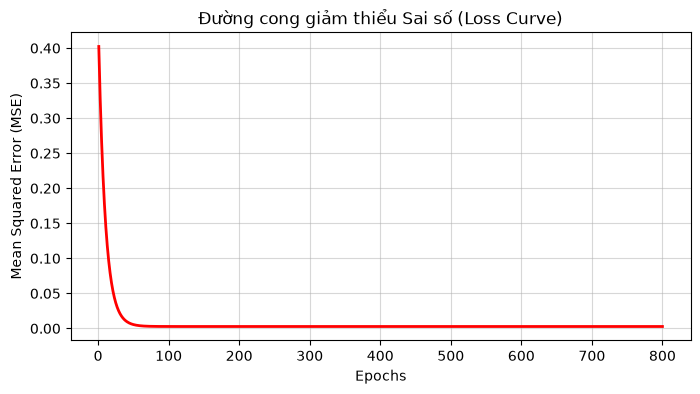

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(model.losses_) + 1), model.losses_, color='red', lw=2)
plt.title('Đường cong giảm thiểu Sai số (Loss Curve)')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True, alpha=0.5)
plt.show()

## 6. Đánh giá và phân tích

Xem lại các mẫu có sai số dự đoán lớn nhất, đọc dấu của trọng số và đối chiếu với trực giác nghiệp vụ.

In [6]:
# Tính sai số
t_pred = model.predict(X_test)
errors = np.abs(t_test - t_pred)
print(f"MSE trên tập Test: {(errors**2).mean():.4f}\n")

# Phân tích 2 mẫu lỗi cao nhất
max_err_idx = np.argsort(errors)[-2:]
print("--- CÁC MẪU CÓ SAI SỐ DỰ ĐOÁN LỚN NHẤT ---")
for idx in max_err_idx:
    print(f"- Thực tế: {t_test[idx]:.3f} | Dự đoán: {t_pred[idx]:.3f} | Lệch: {errors[idx]:.3f}")
    
# Phân tích trọng số
features = ['CO2', 'Nhiệt độ', 'Độ ẩm', 'Số người', 'TG đóng cửa']
print("\n--- PHÂN TÍCH TRỌNG SỐ ---")
for f, w in zip(features, model.w_):
    print(f"{f}: {w:.4f}")
print("-> Nhận xét: CO2 và Nhiệt độ có trọng số dương rất lớn, phù hợp trực giác vì chúng quyết định chính độ ngột ngạt.")

MSE trên tập Test: 0.0033

--- CÁC MẪU CÓ SAI SỐ DỰ ĐOÁN LỚN NHẤT ---
- Thực tế: 0.378 | Dự đoán: 0.494 | Lệch: 0.116
- Thực tế: 0.787 | Dự đoán: 0.649 | Lệch: 0.139

--- PHÂN TÍCH TRỌNG SỐ ---
CO2: 0.0901
Nhiệt độ: 0.0453
Độ ẩm: -0.0014
Số người: 0.0531
TG đóng cửa: 0.0374
-> Nhận xét: CO2 và Nhiệt độ có trọng số dương rất lớn, phù hợp trực giác vì chúng quyết định chính độ ngột ngạt.


## 7. Chọn ngưỡng và thử nghiệm

Nếu cần một quyết định rời rạc (ví dụ cảnh báo/không cảnh báo) từ điểm liên tục, hãy chọn ngưỡng phù hợp và giải thích lựa chọn.

In [7]:
# Chọn ngưỡng Threshold = 0.7 (Mức độ ngột ngạt khá cao mới bật để tiết kiệm điện)
THRESHOLD = 0.7

def discrete_decision(features, desc):
    scaled = (np.array(features) - mean_) / std_
    t_pred = model.predict(scaled)
    decision = "CẦN BẬT QUẠT" if t_pred >= THRESHOLD else "CHƯA CẦN"
    print(f"{desc}: Mức độ dự đoán = {t_pred:.2f} -> Quyết định: {decision}")

print(f"Sử dụng ngưỡng (Threshold) = {THRESHOLD}\n")
discrete_decision([500, 24, 60, 5, 10], "Ca 1 (Mát mẻ, ít người)")
discrete_decision([1200, 30, 65, 20, 60], "Ca 2 (Hơi ngột ngạt)")
discrete_decision([1800, 35, 75, 45, 110], "Ca 3 (Cực kỳ ngột ngạt)")

Sử dụng ngưỡng (Threshold) = 0.7

Ca 1 (Mát mẻ, ít người): Mức độ dự đoán = 0.32 -> Quyết định: CHƯA CẦN
Ca 2 (Hơi ngột ngạt): Mức độ dự đoán = 0.63 -> Quyết định: CHƯA CẦN
Ca 3 (Cực kỳ ngột ngạt): Mức độ dự đoán = 0.95 -> Quyết định: CẦN BẬT QUẠT


## 8. Kết luận

Trả lời ngắn gọn: Adaline với target liên tục có phù hợp hơn Perceptron 0/1 cho tình huống này không? Vì sao? Còn giới hạn gì (ví dụ nếu quan hệ giữa feature và target là phi tuyến, có thể cần MLP)?

**KẾT LUẬN:**
1. **Sự phù hợp:** Adaline với target liên tục cực kỳ phù hợp và vượt trội hơn Perceptron 0/1. Nó cung cấp "mức độ ngột ngạt" (từ 0 đến 1), giúp hệ thống có thể điều khiển tốc độ quạt (ví dụ 0.3 thì bật quạt số nhỏ, 0.9 thì bật quạt hút tối đa), thay vì chỉ biết Bật/Tắt khô cứng.
2. **Giới hạn:** Vì bản chất Adaline vẫn sử dụng hàm tổng tuyến tính ($w^T x + b$), nó không thể nắm bắt được các mối quan hệ phi tuyến phức tạp (ví dụ: nhiệt độ và độ ẩm kết hợp với nhau mới tạo ra độ ngột ngạt đột biến). Nếu dữ liệu phi tuyến mạnh, mô hình Đa tầng (MLP) sẽ là lựa chọn thay thế tốt hơn.